In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sat Jun  4 21:33:25 2022

@author: ixn004
"""
#July 10, 2025


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

#from pyswarm import pso
from pyswarms.single.global_best import GlobalBestPSO #Date: Macrh 30,2024
from calculate_pZAP import run_bionetgen
from interpolation import spline
from ca_ODE import calcium, solve
from interpolation_exp_data import exp_idata


from data_slice import data_after_tstart
from ZAP_SYK_SSR_fit import calculate_residue
from calculate_SSR_gamma import gamma_PZAP
from calculate_SSR_zeta import zeta_PZAP    
from calculate_SSR_mixed import mixed_PZAP
import sys
      


In [6]:
# data_gamma=pd.read_csv('../hCD16_Ca_expt/ca_data/gamma.dat',sep="\t", comment='#', header=None)
# data_zeta=pd.read_csv('../hCD16_Ca_expt/ca_data/zeta.dat',sep="\t", comment='#', header=None)
# data_mixed=pd.read_csv('../hCD16_Ca_expt/ca_data/mixed.dat',sep="\t", comment='#', header=None)


data_gamma=pd.read_csv('../../../hCD16_Ca_expt/ca_data/scaled_data/gamma_scaled.dat',sep="\t", comment='#', header=None)
data_zeta=pd.read_csv('../../../hCD16_Ca_expt/ca_data/scaled_data/zeta_scaled.dat',sep="\t", comment='#', header=None)
data_mixed=pd.read_csv('../../../hCD16_Ca_expt/ca_data/scaled_data/mixed_scaled.dat',sep="\t", comment='#', header=None)

global exp_time_gamma, exp_data_gamma, exp_time_zeta, exp_data_zeta, exp_time_mixed, exp_data_mixed
#if the data has a time column:
start_time=time.time()

data_gamma=np.asarray(data_gamma) 
data_zeta=np.asarray(data_zeta)
data_mixed=np.asarray(data_mixed)

exp_time_gamma=data_gamma[:,0]
exp_data_gamma=data_gamma[:,1]

exp_time_zeta=data_zeta[:,0]
exp_data_zeta=data_zeta[:,1]

exp_time_mixed=data_mixed[:,0]
exp_data_mixed=data_mixed[:,1]





    


In [7]:
#All 3 curves
#estimates=[-2.4449488148175647, -0.3026153422748695, 5.631798668703095, 0.44555561384747805, -1.9427485901941413, 1.3358861405639382, 3.0531451148915383, 2.9207350903093805, 908.5857924281636]
#zeta only
#estimates=[-2.463794962624913, -1.4638041802531272, 5.2554564877037215, 0.13447656522875456, -2.055365670149015, 2.0152354989825363, 2.431260129193699, 2.8856089997131633, 642.4327846094382]
#all 3 curves, changing the range of the adaptor
#estimates=[-0.5096022289089003, -0.6108815439874361, 5.423416208102774, 0.33354722408446597, -2.037423709918416, 2.4159114687819794, 2.477762015271169, 3.4888364104315257, 924.7858084673019]
#CBL =0.001
#estimates=[-1.674381749357385, -0.5692333080276784, 4.974356493830372, 0.03812390290720781, -2.1869438180180296, 2.623192337700126, 2.8824514849992107, 3.3974489121210913, 959.9479289977297]


# K1 = 10**estimates[0]
# K2 = 10**estimates[1]

# C1 = 10**estimates[2]
# C2 = 10**estimates[3]
# g= 10**estimates[4]

# a0 = 10**estimates[5]
# ZAP0 = 10**estimates[6]
# SYK0 = 10**estimates[7] 

K1=0.0026675475345120147
K2=0.1397364395199698

ZAP0=1131.0
SYK0=754.0

C1=10**5.5196370140314786
C2=10**0.5236599922242743
g=10**-2.077672213156433
a0_zeta=(10**2.283148186461748)*5
a0_mixed=10**1.2692534042319892
a0_gamma=10**1.230344436107385


n = 3  # Number of bionetgen runs

dir_name="analysis"
   

In [9]:

tnew_gamma, PZAP_gamma, PSYK_gamma, N, dir_name_gamma = gamma_PZAP(n, K1, K2, a0_gamma, ZAP0, SYK0, dir_name)


k1 = 0.0026675475345120147
k2 = 0.1397364395199698
A0= 16.995910526093105
ZAP0= 1131.0
SYK0= 754.0
Running bionetgen simulations in directory: gamma_runs/analysis


In [11]:

tnew_zeta, PZAP_zeta, PSYK_zeta, N, dir_name_zeta = zeta_PZAP(n, K1, K2, a0_zeta, ZAP0, SYK0, dir_name)

k1 = 0.0026675475345120147
k2 = 0.1397364395199698
A0= 959.6617625265349
ZAP0= 1131.0
SYK0= 754.0
Running bionetgen simulations in directory: zeta_runs/analysis


In [12]:
tnew_mixed, PZAP_mixed, PSYK_mixed, N, dir_name_mixed = mixed_PZAP(n, K1, K2, a0_mixed, ZAP0, SYK0, dir_name)

k1 = 0.0026675475345120147
k2 = 0.1397364395199698
A0= 18.588887720762497
ZAP0= 1131.0
SYK0= 754.0
Running bionetgen simulations in directory: mixed_runs/analysis


In [13]:

residue_zeta,t_zeta,EXPT_zeta,Ca_zeta = calculate_residue(n, tnew_zeta, PZAP_zeta, PSYK_zeta, exp_time_zeta, exp_data_zeta, C1, C2, g, N, dir_name_zeta)
residue_mixed,t_mixed,EXPT_mixed,Ca_mixed = calculate_residue(n, tnew_mixed, PZAP_mixed, PSYK_mixed, exp_time_mixed, exp_data_mixed, C1, C2, g, N, dir_name_mixed)
residue_gamma,t_gamma,EXPT_gamma,Ca_gamma = calculate_residue(n, tnew_gamma, PZAP_gamma, PSYK_gamma, exp_time_gamma, exp_data_gamma, C1, C2, g, N, dir_name_gamma)

C1 = 330854.4757051672
C2 = 3.339335021786436
g = 0.008362339336057479
ca0 in main 38689.53125
[38689.53125    38646.4839791  38603.503546   ... 16165.290885
 16147.3132007  16129.35550973]
C1 = 330854.4757051672
C2 = 3.339335021786436
g = 0.008362339336057479
ca0 in main 41737.61328
[41737.61328    41691.19567737 41644.82967956 ... 19866.99082812
 19844.89642327 19822.82658994]
C1 = 330854.4757051672
C2 = 3.339335021786436
g = 0.008362339336057479
ca0 in main 36345.51172
[36345.51172    36305.09082975 36264.71487666 ... 22363.45499703
 22338.63293686 22313.83797459]


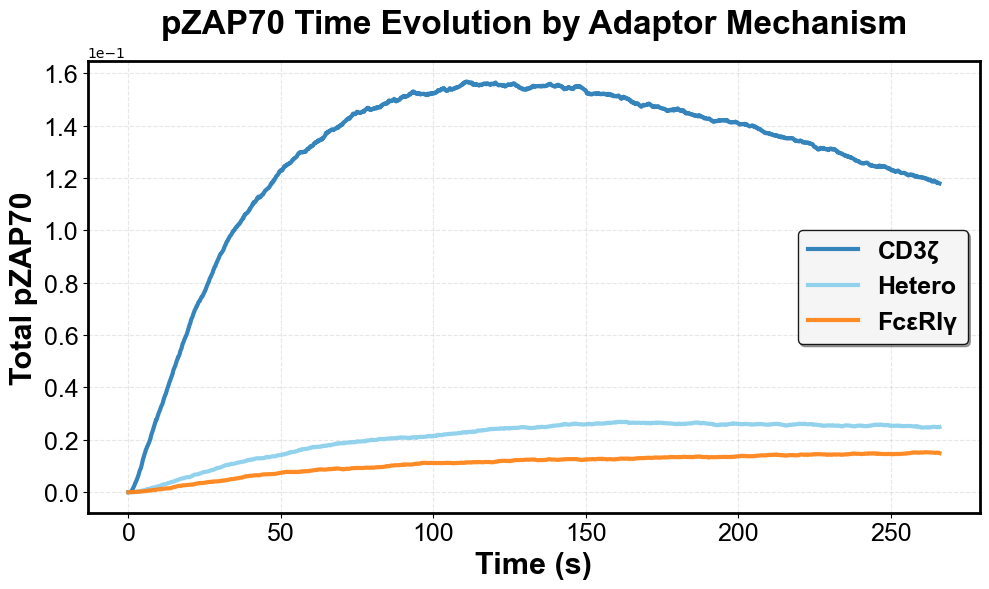

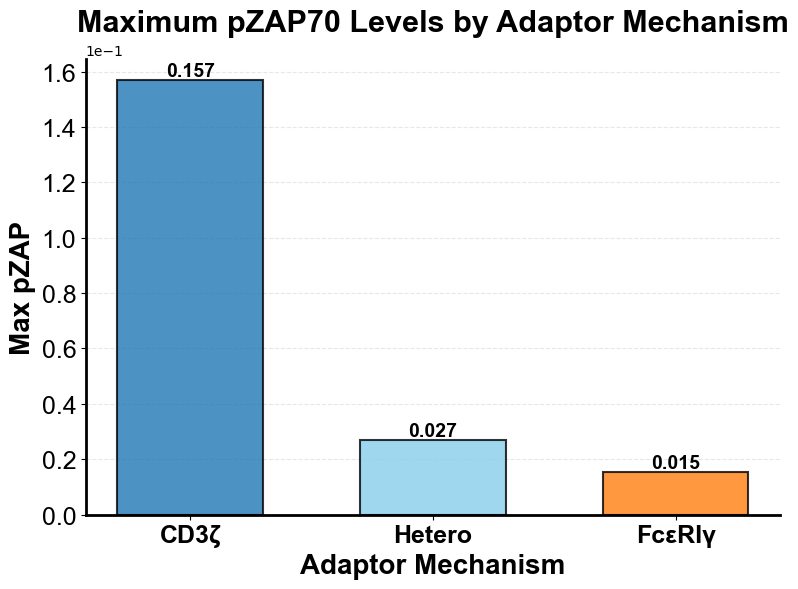

Total residue^(1/4) = 697.8809


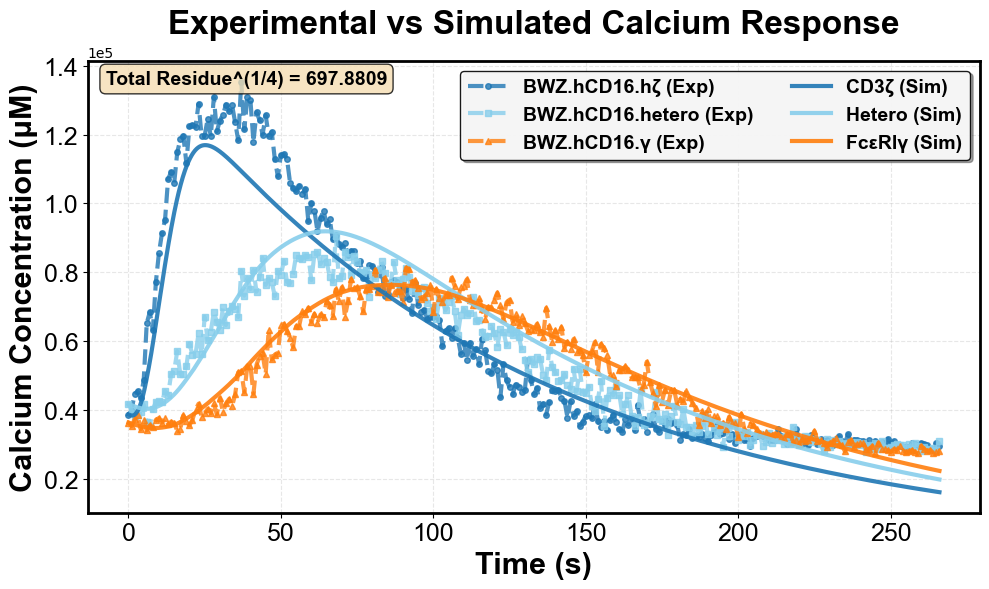

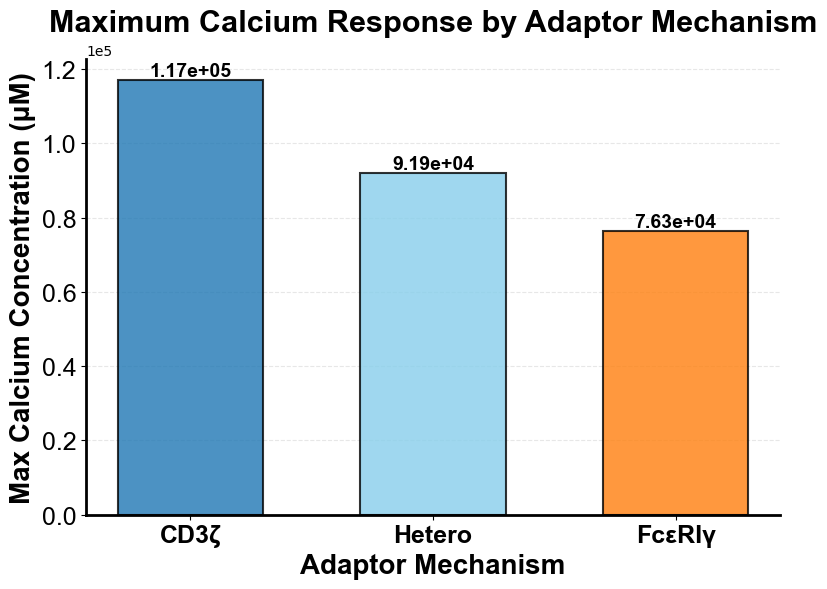

In [14]:
Vc=25.0 #pZAP molecules in the simulation box of size 25 um^3
z=602.0 #constant factor to convert from molecules/um3 to uM

# # Enhanced pZAP time series plot
# fig, ax = plt.subplots(figsize=(10, 6))

# # Plot with enhanced styling
# ax.plot(tnew_zeta, PSYK_zeta, label='CD3ζ', color='#1f77b4', linewidth=3, alpha=0.9)
# ax.plot(tnew_mixed, PSYK_mixed, label='Hetero', color='#87ceeb', linewidth=3, alpha=0.9)
# ax.plot(tnew_gamma, PSYK_gamma, label='FcεRIγ', color='#ff7f0e', linewidth=3, alpha=0.9)

# # Customize labels and title
# ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=22, fontweight='bold')
# ax.set_ylabel('Total pSYK', fontfamily='Arial', fontsize=22, fontweight='bold')
# ax.set_title('pSYK Time Evolution by Adaptor Mechanism', 
#              fontfamily='Arial', fontsize=24, fontweight='bold', pad=20)

# # Enhanced tick formatting
# ax.tick_params(axis='both', which='major', labelsize=18)
# plt.setp(ax.get_xticklabels(), fontfamily='Arial')
# plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# # Enhanced legend
# legend = ax.legend(prop={'family': 'Arial', 'size': 18, 'weight': 'bold'}, 
#                    frameon=True, fancybox=True, shadow=True, 
#                    framealpha=0.9, edgecolor='black')

# # Add grid
# ax.grid(True, alpha=0.3, linestyle='--')
# ax.set_axisbelow(True)

# # Set spine styling
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
#     spine.set_color('black')

# # Scientific notation if needed
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# plt.tight_layout()
# plt.show()


# Enhanced pZAP time series plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot with enhanced styling
ax.plot(tnew_zeta, PZAP_zeta, label='CD3ζ', color='#1f77b4', linewidth=3, alpha=0.9)
ax.plot(tnew_mixed, PZAP_mixed, label='Hetero', color='#87ceeb', linewidth=3, alpha=0.9)
ax.plot(tnew_gamma, PZAP_gamma, label='FcεRIγ', color='#ff7f0e', linewidth=3, alpha=0.9)

# Customize labels and title
ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_ylabel('Total pZAP70', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_title('pZAP70 Time Evolution by Adaptor Mechanism', 
             fontfamily='Arial', fontsize=24, fontweight='bold', pad=20)

# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Enhanced legend
legend = ax.legend(prop={'family': 'Arial', 'size': 18, 'weight': 'bold'}, 
                   frameon=True, fancybox=True, shadow=True, 
                   framealpha=0.9, edgecolor='black')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set spine styling
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Scientific notation if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

# Create figure with better design
fig, ax = plt.subplots(figsize=(8, 6))

# Data and labels
mechanisms = ['CD3ζ', 'Hetero', 'FcεRIγ']
max_values = [np.max(PZAP_zeta), np.max(PZAP_mixed), np.max(PZAP_gamma)]
colors = ['#1f77b4', '#87ceeb', '#ff7f0e']  # Professional color palette

# Create bars with enhanced styling
bars = ax.bar(mechanisms, max_values, 
              color=colors, 
              alpha=0.8,
              edgecolor='black',
              linewidth=1.5,
              width=0.6)

# Add value labels on top of bars
for bar, value in zip(bars, max_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.3f}',
            ha='center', va='bottom', 
            fontfamily='Arial', fontsize=14, fontweight='bold')

# Customize the plot
ax.set_ylabel('Max pZAP', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_xlabel('Adaptor Mechanism', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_title('Maximum pZAP70 Levels by Adaptor Mechanism', 
             fontfamily='Arial', fontsize=22, fontweight='bold', pad=20)

# Set tick parameters
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial', fontweight='bold')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_axisbelow(True)

# Set spine thickness and style
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Scientific notation for y-axis if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Adjust layout and show
plt.tight_layout()
plt.show()


# Enhanced experimental vs simulation calcium plot
fig, ax = plt.subplots(figsize=(10, 6))


# Experimental data with enhanced styling
ax.plot(exp_time_zeta, exp_data_zeta, color='#1f77b4', linewidth=3, 
        linestyle='--', alpha=0.8, label='BWZ.hCD16.hζ (Exp)', marker='o', markersize=4)
ax.plot(exp_time_mixed, exp_data_mixed, color='#87ceeb', linewidth=3, 
        linestyle='--', alpha=0.8, label='BWZ.hCD16.hetero (Exp)', marker='s', markersize=4)
ax.plot(exp_time_gamma, exp_data_gamma, color='#ff7f0e', linewidth=3, 
        linestyle='--', alpha=0.8, label='BWZ.hCD16.γ (Exp)', marker='^', markersize=4)

# Simulation data with solid lines
ax.plot(t_zeta, Ca_zeta, color='#1f77b4', linewidth=3, alpha=0.9, label='CD3ζ (Sim)')
ax.plot(t_mixed, Ca_mixed, color='#87ceeb', linewidth=3, alpha=0.9, label='Hetero (Sim)')
ax.plot(t_gamma, Ca_gamma, color='#ff7f0e', linewidth=3, alpha=0.9, label='FcεRIγ (Sim)')

# Calculate and display residue
residue_total = residue_zeta + residue_mixed + residue_gamma
print(f"Total residue^(1/4) = {residue_total**(1/4):.4f}")

# Enhanced labels and title
ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_ylabel('Calcium Concentration (μM)', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_title('Experimental vs Simulated Calcium Response', 
             fontfamily='Arial', fontsize=24, fontweight='bold', pad=20)

# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Enhanced legend with two columns
legend = ax.legend(prop={'family': 'Arial', 'size': 14, 'weight': 'bold'}, 
                   frameon=True, fancybox=True, shadow=True, 
                   framealpha=0.9, edgecolor='black', ncol=2, loc='upper right')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set spine styling
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Scientific notation if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Add text box with residue information
textstr = f'Total Residue^(1/4) = {residue_total**(1/4):.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props, fontfamily='Arial', fontweight='bold')

plt.tight_layout()
plt.show()

# Enhanced maximum calcium bar plot
fig, ax = plt.subplots(figsize=(8, 6))

# Data and labels
mechanisms = ['CD3ζ', 'Hetero', 'FcεRIγ']
max_calcium_values = [np.max(Ca_zeta), np.max(Ca_mixed), np.max(Ca_gamma)]
colors = ['#1f77b4', '#87ceeb', '#ff7f0e']  # Professional color palette

# Create bars with enhanced styling
bars = ax.bar(mechanisms, max_calcium_values, 
              color=colors, 
              alpha=0.8,
              edgecolor='black',
              linewidth=1.5,
              width=0.6)

# Add value labels on top of bars
for bar, value in zip(bars, max_calcium_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.2e}',
            ha='center', va='bottom', 
            fontfamily='Arial', fontsize=14, fontweight='bold')

# Customize the plot
ax.set_ylabel('Max Calcium Concentration (μM)', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_xlabel('Adaptor Mechanism', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_title('Maximum Calcium Response by Adaptor Mechanism', 
             fontfamily='Arial', fontsize=22, fontweight='bold', pad=20)

# Set tick parameters
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial', fontweight='bold')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_axisbelow(True)

# Set spine thickness and style
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Scientific notation for y-axis
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Adjust layout and show
plt.tight_layout()
plt.show()
